# 🔬 Step 4 — RawNet2 + SincNet Learnable Frontend

## What this notebook does

Your project already has RawNet2 in `src/models/vocoder/` with pretrained weights (`librifake_pretrained_lambda0.5_epoch_25.pth`).  
**Step 4 improves it** by replacing its fixed sinc filters with a **SincNet-style learnable frontend** — the model now learns *which frequency bands matter* for detecting deepfakes, instead of using hardcoded ones.

### The improvement at a glance
```
BEFORE (original):  Raw Audio → Fixed sinc filters → RawNet2 body → Score
AFTER  (step 4):    Raw Audio → Learnable SincNet filters → RawNet2 body → Score
                                       ↑
                          Frequencies are now trained parameters
                          You can visualize what it learned
```

### Training strategy
- **Phase 1**: Freeze RawNet2 body, train only SincNet frontend (~10 epochs)
- **Phase 2**: Unfreeze full model, fine-tune end-to-end (~10 epochs)
- Every epoch: checkpoint saved to `/kaggle/working/` and pushed to HuggingFace
- Best model (lowest dev EER) also pushed separately

### Maps to
`src/models/vocoder/` in your project

---
> ⚙️ **Before running:**
> 1. Settings → Accelerator → **GPU T4 x2** → Internet **ON**
> 2. Add Data → search **ASVspoof 2019** → add it
> 3. Upload your `librifake_pretrained_lambda0.5_epoch_25.pth` as a Kaggle Dataset
> 4. Fill in Section 1 (HF token, repo ID, paths)

## Where to Get RawNet2 — Read Before Running

Your project already has RawNet2. Here is a full map of what you already have vs what this notebook adds:

| What | Where in your project | Status |
|------|----------------------|--------|
| RawNet2 architecture code | `src/models/vocoder/` | ✅ Already exists |
| Pretrained weights | `weights/librifake_pretrained_lambda0.5_epoch_25.pth` | ✅ Already exists |
| SincNet learnable frontend | `src/models/vocoder/sincnet.py` (new file) | 🆕 This notebook creates it |
| Fine-tuned weights | `weights/rawnet2_sincnet_finetuned.pth` | 🆕 This notebook trains it |

**Getting your existing weights onto Kaggle:**
1. Go to kaggle.com → Datasets → New Dataset
2. Upload your `librifake_pretrained_lambda0.5_epoch_25.pth` file
3. Name it `rawnet2-librifake-weights`
4. In this notebook: Add Data → search `rawnet2-librifake-weights` → add it
5. It will appear at `/kaggle/input/rawnet2-librifake-weights/librifake_pretrained_lambda0.5_epoch_25.pth`

**Official RawNet2 reference** (if you need to rebuild the architecture from scratch):  
https://github.com/asvspoof-challenge/2021/tree/main/LA/Baseline-RawNet2

## 0. Install & Imports

In [43]:
!pip install -q transformers huggingface_hub torchaudio librosa matplotlib seaborn scikit-learn

In [44]:
import os, json, random, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T

from huggingface_hub import HfApi, login, create_repo
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
print(f"Device : {DEVICE}  |  GPUs available : {N_GPUS}")
for i in range(N_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}  "
          f"({torch.cuda.get_device_properties(i).total_memory // 1e9:.0f} GB)")

Device : cuda  |  GPUs available : 2
  GPU 0: Tesla T4  (15 GB)
  GPU 1: Tesla T4  (15 GB)


## 1. Configuration — ✏️ Edit These Before Running

In [45]:
from kaggle_secrets import UserSecretsClient

# Load token securely from Kaggle Secrets
secrets = UserSecretsClient()
HF_TOKEN = secrets.get_secret("HF_TOKEN")
HF_REPO_ID = "IshatShivhare/deepfake-rawnet2-sincnet" # will be created if absent

# Kaggle paths — adjust if your dataset folder name differs
# Run !ls /kaggle/input/ in a new cell to confirm folder names
DATA_ROOT     = "/kaggle/input/datasets/anishsarkar22/asvpoof-2019-dataset-la/LA"
PRETRAINED_WEIGHTS = ("/kaggle/input/datasets/ishatshivhare/rawnet2-librifake-weights/pre_trained_DF_RawNet2.pth")

# ─────────────────────────────────────────────────────────────────────────────
#  HYPERPARAMETERS
# ─────────────────────────────────────────────────────────────────────────────
CFG = dict(
    # Audio
    sample_rate       = 16000,
    max_audio_len_sec = 4.0,

    # SincNet frontend
    sinc_num_filters  = 128,       # number of learnable bandpass filters
    sinc_kernel_size  = 251,       # must be odd
    sinc_min_low_hz   = 50,        # minimum low cutoff frequency (Hz)
    sinc_min_band_hz  = 50,        # minimum bandwidth (Hz)

    # RawNet2 body
    rawnet2_filters   = [20, 64],  # ResBlock filter sizes — must match pretrained weights
    rawnet2_gru_nodes = 1024,
    rawnet2_gru_layers= 3,
    rawnet2_nb_fc_node= 1024,
    rawnet2_nb_classes= 2,

    # Training
    batch_size        = 64,
    num_workers       = 4,
    lr_sinc           = 1e-3,      # Phase 1: frontend only
    lr_full           = 5e-5,      # Phase 2: full model
    weight_decay      = 2e-4,
    epochs_phase1     = 10,        # freeze body, train SincNet
    epochs_phase2     = 10,        # unfreeze all, fine-tune end-to-end
    grad_clip         = 1.0,

    # Paths
    checkpoint_dir    = "/kaggle/working/checkpoints",
    output_dir        = "/kaggle/working/outputs",
)

MAX_LEN = int(CFG["sample_rate"] * CFG["max_audio_len_sec"])
os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
os.makedirs(CFG["output_dir"],     exist_ok=True)

print("Config ready ✓")
print(json.dumps({k: v for k, v in CFG.items() if not k.endswith("dir")}, indent=2))

Config ready ✓
{
  "sample_rate": 16000,
  "max_audio_len_sec": 4.0,
  "sinc_num_filters": 128,
  "sinc_kernel_size": 251,
  "sinc_min_low_hz": 50,
  "sinc_min_band_hz": 50,
  "rawnet2_filters": [
    20,
    64
  ],
  "rawnet2_gru_nodes": 1024,
  "rawnet2_gru_layers": 3,
  "rawnet2_nb_fc_node": 1024,
  "rawnet2_nb_classes": 2,
  "batch_size": 64,
  "num_workers": 4,
  "lr_sinc": 0.001,
  "lr_full": 5e-05,
  "weight_decay": 0.0002,
  "epochs_phase1": 10,
  "epochs_phase2": 10,
  "grad_clip": 1.0
}


## 2. HuggingFace Login (done early so checkpoints can upload mid-training)

In [46]:
login(token=HF_TOKEN)
api = HfApi()

create_repo(HF_REPO_ID, token=HF_TOKEN, private=False, exist_ok=True)
print(f"HuggingFace repo ready: https://huggingface.co/{HF_REPO_ID}")

def hf_upload(local_path: str, repo_path: str, commit_msg: str = "update"):
    """Upload a single file to HuggingFace Hub. Called after every checkpoint."""
    if not os.path.exists(local_path):
        print(f"  [HF] File not found, skipping: {local_path}")
        return
    try:
        api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = repo_path,
            repo_id         = HF_REPO_ID,
            token           = HF_TOKEN,
            commit_message  = commit_msg,
        )
        print(f"  ✓ HF upload: {repo_path}")
    except Exception as e:
        print(f"  ✗ HF upload failed ({repo_path}): {e}")

print("HF upload helper ready ✓")

HuggingFace repo ready: https://huggingface.co/IshatShivhare/deepfake-rawnet2-sincnet
HF upload helper ready ✓


## 3. Dataset

In [47]:
def parse_protocol(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.strip().split()
            rows.append({"speaker": p[0], "file": p[1],
                         "system": p[3], "label": 0 if p[4]=="bonafide" else 1})
    return pd.DataFrame(rows)

proto_dir   = os.path.join(DATA_ROOT, "ASVspoof2019_LA_cm_protocols")
train_df    = parse_protocol(os.path.join(proto_dir, "ASVspoof2019.LA.cm.train.trn.txt"))
dev_df      = parse_protocol(os.path.join(proto_dir, "ASVspoof2019.LA.cm.dev.trl.txt"))
eval_df     = parse_protocol(os.path.join(proto_dir, "ASVspoof2019.LA.cm.eval.trl.txt"))

train_audio = os.path.join(DATA_ROOT, "ASVspoof2019_LA_train", "flac")
dev_audio   = os.path.join(DATA_ROOT, "ASVspoof2019_LA_dev",   "flac")
eval_audio  = os.path.join(DATA_ROOT, "ASVspoof2019_LA_eval",  "flac")

print(f"Train : {len(train_df):,}  ({train_df.label.sum():,} spoof / {(train_df.label==0).sum():,} real)")
print(f"Dev   : {len(dev_df):,}")
print(f"Eval  : {len(eval_df):,}")

Train : 25,380  (22,800 spoof / 2,580 real)
Dev   : 24,844
Eval  : 71,237


In [48]:
class RawAudioDataset(Dataset):
    """
    Returns raw waveforms — no MFCCs, no feature extraction.
    RawNet2 + SincNet operate directly on the waveform.
    """
    def __init__(self, df, audio_dir, max_len=MAX_LEN, sr=16000, augment=False):
        self.df        = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.max_len   = max_len
        self.sr        = sr
        self.augment   = augment

    def _load(self, fname):
        path = os.path.join(self.audio_dir, fname + ".flac")
        wav, sr = torchaudio.load(path)
        if wav.shape[0] > 1:
            wav = wav.mean(0, keepdim=True)
        if sr != self.sr:
            wav = T.Resample(sr, self.sr)(wav)
        wav = wav.squeeze(0)  # [T]
        # Pad or trim
        if wav.shape[0] < self.max_len:
            wav = F.pad(wav, (0, self.max_len - wav.shape[0]))
        else:
            # Random crop during training for augmentation
            if self.augment and wav.shape[0] > self.max_len:
                start = random.randint(0, wav.shape[0] - self.max_len)
                wav = wav[start: start + self.max_len]
            else:
                wav = wav[:self.max_len]
        return wav

    def _augment_waveform(self, wav):
        """Light augmentation: additive Gaussian noise and random gain."""
        if random.random() < 0.4:
            noise = torch.randn_like(wav) * random.uniform(0.001, 0.005)
            wav = wav + noise
        if random.random() < 0.3:
            gain = random.uniform(0.7, 1.3)
            wav = wav * gain
        return wav.clamp(-1.0, 1.0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = self._load(row["file"])
        if self.augment:
            wav = self._augment_waveform(wav)
        return wav.unsqueeze(0), torch.tensor(row["label"], dtype=torch.long)
        # Returns [1, T], label

print("Dataset class defined ✓")

Dataset class defined ✓


In [49]:
# Weighted sampler to handle class imbalance
labels_arr  = train_df["label"].values
class_count = np.bincount(labels_arr)
sample_wts  = 1.0 / class_count[labels_arr]
sampler     = torch.utils.data.WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

train_ds = RawAudioDataset(train_df, train_audio, augment=True)
dev_ds   = RawAudioDataset(dev_df,   dev_audio,   augment=False)
eval_ds  = RawAudioDataset(eval_df,  eval_audio,  augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], sampler=sampler,
                          num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
dev_loader   = DataLoader(dev_ds,   batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
eval_loader  = DataLoader(eval_ds,  batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Dev   batches : {len(dev_loader)}")
print(f"Eval  batches : {len(eval_loader)}")

Train batches : 396
Dev   batches : 389
Eval  batches : 1114


## 4. Model Architecture

### 4a. SincNet Learnable Frontend (Step 4 — the core improvement)

**What is SincNet?**  
Instead of using a standard Conv1d layer with random weights, SincNet constrains the filters to be **bandpass filters** defined by two learnable parameters per filter: a low cutoff frequency and a bandwidth. This means:
- Every filter is physically interpretable (it's just a frequency band)
- The model learns which frequency bands matter for deepfake detection
- You can visualize the learned filters as a frequency response plot
- Far fewer parameters than unconstrained convolutions

**Original RawNet2** uses a fixed sinc filter layer. This notebook makes those filters **trainable**.

In [50]:
class SincConv1d(nn.Module):
    """
    Learnable SincNet frontend — replaces the fixed sinc filters in RawNet2.
    
    Each filter is parameterized as a bandpass filter:
        h[t] = 2*f_high*sinc(2*f_high*t) - 2*f_low*sinc(2*f_low*t)
    where f_low and bandwidth are the TWO learnable parameters per filter.
    
    Maps to: src/models/vocoder/sincnet.py
    """
    def __init__(self, num_filters: int, kernel_size: int, sample_rate: int = 16000,
                 min_low_hz: float = 50.0, min_band_hz: float = 50.0,
                 stride: int = 1, padding: int = 0):
        super().__init__()
        assert kernel_size % 2 == 1, "kernel_size must be odd"

        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        self.min_low_hz  = min_low_hz
        self.min_band_hz = min_band_hz
        self.stride      = stride
        self.padding     = padding

        # ── Initialise filter bank with mel-scale spacing ─────────────────────
        # Mel-scale gives better coverage of perceptually important frequencies
        low_hz  = 30.0
        high_hz = sample_rate / 2 - (min_low_hz + min_band_hz)

        mel_low  = self._hz_to_mel(low_hz)
        mel_high = self._hz_to_mel(high_hz)
        mel_pts  = torch.linspace(mel_low, mel_high, num_filters + 1)
        hz_pts   = self._mel_to_hz(mel_pts)

        # Learnable parameters: low cutoff and bandwidth (both in Hz, stored /sample_rate)
        self.low_hz_  = nn.Parameter(hz_pts[:-1].unsqueeze(1))   # [F, 1]
        self.band_hz_ = nn.Parameter((hz_pts[1:] - hz_pts[:-1]).unsqueeze(1))  # [F, 1]

        # Fixed Hamming window (not learnable — just for smooth filter edges)
        n_half = (kernel_size - 1) / 2
        n      = torch.arange(-n_half, 0).float()
        window = 0.54 - 0.46 * torch.cos(2 * math.pi * n / (kernel_size - 1))
        self.register_buffer("n_",      n / sample_rate)        # [kernel/2]
        self.register_buffer("window_", window)                 # [kernel/2]

    @staticmethod
    def _hz_to_mel(hz): return 2595 * np.log10(1 + hz / 700)
    @staticmethod
    def _mel_to_hz(mel): return 700 * (10 ** (mel / 2595) - 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, T]
        # Enforce physical constraints: cutoffs must be positive
        low  = self.min_low_hz / self.sample_rate + torch.abs(self.low_hz_ / self.sample_rate)
        high = low + self.min_band_hz / self.sample_rate + torch.abs(self.band_hz_ / self.sample_rate)
        high = torch.clamp(high, max=0.5)  # Nyquist limit

        # Build filters using sinc difference (bandpass)
        # n_: [kernel/2], broadcasted against [F, 1]
        n = self.n_.unsqueeze(0)                           # [1, kernel/2]

        f_low  = 2 * low  * torch.sinc(2 * low  * n)     # [F, kernel/2]
        f_high = 2 * high * torch.sinc(2 * high * n)     # [F, kernel/2]
        band   = (f_high - f_low) * self.window_          # [F, kernel/2]

        # Build full symmetric filter
        filters = torch.cat([
            torch.flip(band, dims=[1]),                   # left half
            (2 * high - 2 * low).squeeze(1).unsqueeze(1), # center (DC)
            band                                          # right half
        ], dim=1)                                         # [F, kernel_size]

        filters = filters.unsqueeze(1)                    # [F, 1, kernel_size]
        return F.conv1d(x, filters, stride=self.stride,
                        padding=self.padding, bias=None)  # [B, F, T']

    def get_learned_frequencies(self):
        """Return (low_hz, high_hz) arrays for visualization."""
        with torch.no_grad():
            low  = (self.min_low_hz + torch.abs(self.low_hz_)).squeeze().cpu().numpy()
            band = (self.min_band_hz + torch.abs(self.band_hz_)).squeeze().cpu().numpy()
        return low, low + band

print("SincConv1d defined ✓")

SincConv1d defined ✓


### 4b. RawNet2 Architecture
This is the same RawNet2 body that's in your `src/models/vocoder/` — reproduced here so the notebook is self-contained on Kaggle. The SincConv1d above **replaces** the first layer.

In [51]:
class FMS(nn.Module):
    """Feature Map Scaling — channel-wise attention used inside RawNet2 ResBlocks."""
    def __init__(self, num_channels: int):
        super().__init__()
        self.fc  = nn.Linear(num_channels, num_channels)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        # x: [B, C, T]
        pooled = x.mean(dim=-1)                        # [B, C]
        scale  = self.sig(self.fc(pooled)).unsqueeze(-1)  # [B, C, 1]
        return x * scale + x                           # residual scaling


class ResBlock(nn.Module):
    """RawNet2 residual block with BatchNorm + FMS."""
    def __init__(self, in_channels: int, out_channels: int, first: bool = False):
        super().__init__()
        self.first = first
        if not first:
            self.bn1 = nn.BatchNorm1d(in_channels)
        self.lrelu = nn.LeakyReLU(0.3)
        self.conv1 = nn.Conv1d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, 3, padding=1, bias=False)
        self.mp    = nn.MaxPool1d(3)
        self.fms   = FMS(out_channels)
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm1d(out_channels),
            )
        else:
            self.downsample = None

    def forward(self, x):
        identity = x
        if not self.first:
            x = self.bn1(x)
        x = self.lrelu(x)
        x = self.conv1(x)
        x = self.bn2(x)
        x = self.lrelu(x)
        x = self.conv2(x)
        if self.downsample:
            identity = self.downsample(identity)
        x = x + identity
        x = self.mp(x)
        x = self.fms(x)
        return x


class RawNet2WithSincNet(nn.Module):
    """
    Full RawNet2 with learnable SincNet frontend.
    
    Architecture:
        Raw Audio [B,1,T]
            → SincConv1d (learnable bandpass filters)    ← STEP 4
            → BN → LeakyReLU → MaxPool
            → ResBlock x6 (original RawNet2 body)
            → GRU
            → FC → Softmax
    
    Maps to: src/models/vocoder/ in your project
    """
    def __init__(
        self,
        sinc_num_filters : int   = 128,
        sinc_kernel_size : int   = 251,
        sinc_min_low_hz  : float = 50.0,
        sinc_min_band_hz : float = 50.0,
        filts            : list  = [20, 64],
        gru_node         : int   = 1024,
        nb_gru_layer     : int   = 3,
        nb_fc_node       : int   = 1024,
        nb_classes       : int   = 2,
        sample_rate      : int   = 16000,
    ):
        super().__init__()

        # ── SincNet frontend ─────────────────────────────────────────────────
        self.sinc_conv = SincConv1d(
            num_filters  = sinc_num_filters,
            kernel_size  = sinc_kernel_size,
            sample_rate  = sample_rate,
            min_low_hz   = sinc_min_low_hz,
            min_band_hz  = sinc_min_band_hz,
            padding      = sinc_kernel_size // 2,
        )
        self.bn_sinc  = nn.BatchNorm1d(sinc_num_filters)
        self.lrelu    = nn.LeakyReLU(0.3)
        self.mp_sinc  = nn.MaxPool1d(3)
        self.drop_sinc= nn.Dropout(0.3)

        # ── RawNet2 ResBlock body ────────────────────────────────────────────
        # filts[0] = 20, filts[1] = 64  (must match pretrained weights)
        self.block0 = ResBlock(sinc_num_filters, filts[0], first=True)
        self.block1 = ResBlock(filts[0],         filts[0])
        self.block2 = ResBlock(filts[0],         filts[1])
        self.block3 = ResBlock(filts[1],         filts[1])
        self.block4 = ResBlock(filts[1],         filts[1])
        self.block5 = ResBlock(filts[1],         filts[1])
        self.bn_before_gru = nn.BatchNorm1d(filts[1])

        # ── GRU ─────────────────────────────────────────────────────────────
        self.gru = nn.GRU(
            input_size   = filts[1],
            hidden_size  = gru_node,
            num_layers   = nb_gru_layer,
            batch_first  = True,
            dropout      = 0.1 if nb_gru_layer > 1 else 0,
        )

        # ── Classifier ───────────────────────────────────────────────────────
        self.fc    = nn.Linear(gru_node, nb_fc_node)
        self.out   = nn.Linear(nb_fc_node, nb_classes)
        self.drop  = nn.Dropout(0.3)
        self.sig   = nn.Sigmoid()

    # ── Freeze / unfreeze helpers ─────────────────────────────────────────────
    def freeze_body(self):
        """Phase 1: Only SincNet frontend trains."""
        for name, param in self.named_parameters():
            param.requires_grad = name.startswith("sinc_conv")
        print(f"Frozen body — trainable params: {self.trainable_params():,}")

    def unfreeze_all(self):
        """Phase 2: Full model trains."""
        for param in self.parameters():
            param.requires_grad = True
        print(f"Unfrozen all — trainable params: {self.trainable_params():,}")

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_params(self):
        return sum(p.numel() for p in self.parameters())

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor):
        # x: [B, 1, T]

        # SincNet frontend
        x = self.sinc_conv(x)                         # [B, F_sinc, T]
        x = torch.abs(x)                              # Absolute value (common in SincNet)
        x = self.bn_sinc(x)
        x = self.lrelu(x)
        x = self.mp_sinc(x)
        x = self.drop_sinc(x)

        # ResBlock body
        x = self.block0(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.bn_before_gru(x)
        x = self.lrelu(x)

        # GRU expects [B, T, C]
        x = x.permute(0, 2, 1)                        # [B, T', filts[1]]
        x, _ = self.gru(x)                            # [B, T', gru_node]
        x = x[:, -1, :]                               # last timestep [B, gru_node]

        # Classifier
        x = self.fc(x)
        x = self.lrelu(x)
        x = self.drop(x)
        x = self.out(x)                               # [B, 2]
        return x

print("RawNet2WithSincNet defined ✓")

RawNet2WithSincNet defined ✓


### 4c. Load Pretrained Weights
We load your existing `librifake_pretrained_lambda0.5_epoch_25.pth` into the **body** of the model (ResBlocks + GRU + FC). The SincNet frontend starts from its mel-scale initialization and is trained fresh.

In [52]:
def load_pretrained_body(model: RawNet2WithSincNet, ckpt_path: str) -> dict:
    """
    Load pretrained RawNet2 weights into the model body only.
    Skips the SincNet frontend (different param name / shape).
    Returns a report of matched / skipped keys.
    """
    if not os.path.exists(ckpt_path):
        print(f"⚠️  Pretrained weights not found at {ckpt_path}")
        print("    Continuing with random initialisation.")
        return {}

    pretrained = torch.load(ckpt_path, map_location="cpu")

    # Handle various checkpoint formats
    if isinstance(pretrained, dict):
        state = (pretrained.get("model_state_dict")
                 or pretrained.get("state_dict")
                 or pretrained)
    else:
        state = pretrained

    model_state = model.state_dict()
    matched, skipped_shape, skipped_missing = [], [], []

    for k, v in state.items():
        # Strip 'module.' prefix if pretrained with DataParallel
        k = k.replace("module.", "")
        # Skip the original sinc filter (we have our own learnable one)
        if "sinc" in k.lower() or "Sinc" in k:
            skipped_missing.append(k)
            continue
        if k not in model_state:
            skipped_missing.append(k)
            continue
        if model_state[k].shape != v.shape:
            skipped_shape.append(f"{k}: pretrained {tuple(v.shape)} vs model {tuple(model_state[k].shape)}")
            continue
        model_state[k] = v
        matched.append(k)

    model.load_state_dict(model_state, strict=False)

    print(f"Pretrained weights loaded from: {ckpt_path}")
    print(f"  ✓ Matched keys     : {len(matched)}")
    print(f"  ⚠ Shape mismatch   : {len(skipped_shape)}")
    print(f"  ℹ Not in model     : {len(skipped_missing)}")
    if skipped_shape:
        for s in skipped_shape:
            print(f"    {s}")
    return {"matched": matched, "skipped_shape": skipped_shape, "skipped_missing": skipped_missing}


# ── Instantiate & load ────────────────────────────────────────────────────────
model = RawNet2WithSincNet(
    sinc_num_filters = CFG["sinc_num_filters"],
    sinc_kernel_size = CFG["sinc_kernel_size"],
    sinc_min_low_hz  = CFG["sinc_min_low_hz"],
    sinc_min_band_hz = CFG["sinc_min_band_hz"],
    filts            = CFG["rawnet2_filters"],
    gru_node         = CFG["rawnet2_gru_nodes"],
    nb_gru_layer     = CFG["rawnet2_gru_layers"],
    nb_fc_node       = CFG["rawnet2_nb_fc_node"],
    nb_classes       = CFG["rawnet2_nb_classes"],
    sample_rate      = CFG["sample_rate"],
).to(DEVICE)

load_report = load_pretrained_body(model, PRETRAINED_WEIGHTS)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel across {N_GPUS} GPUs")

core = model.module if isinstance(model, nn.DataParallel) else model
print(f"\nTotal params     : {core.total_params():,}")

Pretrained weights loaded from: /kaggle/input/datasets/ishatshivhare/rawnet2-librifake-weights/pre_trained_DF_RawNet2.pth
  ✓ Matched keys     : 12
  ⚠ Shape mismatch   : 5
  ℹ Not in model     : 102
    bn_before_gru.weight: pretrained (128,) vs model (64,)
    bn_before_gru.bias: pretrained (128,) vs model (64,)
    bn_before_gru.running_mean: pretrained (128,) vs model (64,)
    bn_before_gru.running_var: pretrained (128,) vs model (64,)
    gru.weight_ih_l0: pretrained (3072, 128) vs model (3072, 64)
DataParallel across 2 GPUs

Total params     : 17,119,650


## 5. Training Utilities

In [53]:
def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2), float(thresholds[idx])


def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, all_labels, all_scores = 0.0, [], []

    with (torch.enable_grad() if train else torch.no_grad()):
        for wav, labels in loader:
            wav, labels = wav.to(DEVICE), labels.to(DEVICE)
            logits = model(wav)                              # [B, 2]
            loss   = criterion(logits, labels)

            if train and optimizer:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                optimizer.step()

            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)[:, 1]          # P(spoof)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_scores)
    eer, _   = compute_eer(np.array(all_labels), np.array(all_scores))
    acc      = ((np.array(all_scores) > 0.5) == np.array(all_labels)).mean()
    return avg_loss, auc, eer, acc, all_labels, all_scores


def save_checkpoint(model, optimizer, scheduler, epoch, phase, metrics, tag=""):
    """
    Save a full resumable checkpoint locally AND push it to HuggingFace.
    """
    core = model.module if isinstance(model, nn.DataParallel) else model
    ckpt = {
        "epoch"            : epoch,
        "phase"            : phase,
        "model_state_dict" : core.state_dict(),
        "optimizer_state"  : optimizer.state_dict(),
        "scheduler_state"  : scheduler.state_dict() if scheduler else None,
        "metrics"          : metrics,
        "config"           : CFG,
    }
    fname      = f"rawnet2_sincnet_{phase}_ep{epoch:02d}{tag}.pth"
    local_path = os.path.join(CFG["checkpoint_dir"], fname)
    torch.save(ckpt, local_path)

    # Push to HuggingFace
    hf_upload(
        local_path,
        f"checkpoints/{fname}",
        commit_msg=f"{phase} epoch {epoch} | EER={metrics['dev_eer']*100:.2f}% | AUC={metrics['dev_auc']:.4f}"
    )
    return local_path


print("Training utilities defined ✓")

Training utilities defined ✓


## 6. Phase 1 — Train SincNet Frontend Only (Body Frozen)

In [54]:
# ── Phase 1 Setup ─────────────────────────────────────────────────────────────
core = model.module if isinstance(model, nn.DataParallel) else model
core.freeze_body()

criterion = nn.CrossEntropyLoss(weight=torch.tensor(
    [1.0, class_count[0]/class_count[1]], dtype=torch.float32
).to(DEVICE))

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_sinc"], weight_decay=CFG["weight_decay"]
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=CFG["epochs_phase1"], eta_min=1e-6
)

history      = defaultdict(list)
best_p1_eer  = float("inf")
best_p1_path = None
start_epoch  = 1

# ── Auto-resume: find last phase1 checkpoint on HF ───────────────────────────
resume_ckpt_p1 = os.path.join(CFG["checkpoint_dir"], "resume_phase1.pth")

if not os.path.exists(resume_ckpt_p1):
    print("No local phase1 resume — scanning HF for latest phase1 checkpoint...")
    try:
        from huggingface_hub import hf_hub_download
        import shutil
        # Find the last epoch saved (scan ep10 down to ep01)
        for ep in range(CFG["epochs_phase1"], 0, -1):
            for tag in [f"_ep{ep:02d}.pth", f"_ep{ep:02d}_best.pth"]:
                fname = f"rawnet2_sincnet_phase1{tag}"
                try:
                    downloaded = hf_hub_download(
                        repo_id=HF_REPO_ID,
                        filename=f"checkpoints/{fname}",
                        token=HF_TOKEN,
                    )
                    shutil.copy(downloaded, resume_ckpt_p1)
                    print(f"⚡ Pulled from HF: {fname} → using as resume")
                    break
                except Exception:
                    continue
            if os.path.exists(resume_ckpt_p1):
                break
        if not os.path.exists(resume_ckpt_p1):
            print("No HF phase1 checkpoint found — fresh start.")
    except Exception as e:
        print(f"HF scan failed — fresh start. ({e})")

if os.path.exists(resume_ckpt_p1):
    print("⚡ Phase 1 resume checkpoint found — loading...")
    ckpt = torch.load(resume_ckpt_p1, map_location=DEVICE, weights_only=False)
    core.load_state_dict(ckpt["model_state_dict"])
    optimizer_p1.load_state_dict(ckpt["optimizer_state"])
    if ckpt.get("scheduler_state"):
        scheduler_p1.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    print(f"  ↳ Resuming from epoch {ckpt['epoch']}/{CFG['epochs_phase1']}")
else:
    print("Starting Phase 1 from epoch 1.")

print("=" * 70)
print("PHASE 1 — SincNet Frontend Training (RawNet2 body frozen)")
print("=" * 70)

Frozen body — trainable params: 256
⚡ Phase 1 resume checkpoint found — loading...
  ↳ Resuming from epoch 10/10
PHASE 1 — SincNet Frontend Training (RawNet2 body frozen)


In [55]:
if start_epoch > CFG["epochs_phase1"]:
    print("✓ Phase 1 already fully completed — skipping.")
else:
    for epoch in range(start_epoch, CFG["epochs_phase1"] + 1):
        tr_loss, tr_auc, tr_eer, tr_acc, _, _ = run_epoch(
            model, train_loader, criterion, optimizer_p1, train=True)
        dv_loss, dv_auc, dv_eer, dv_acc, _, _ = run_epoch(
            model, dev_loader, criterion, train=False)
        scheduler_p1.step()

        metrics = dict(train_loss=tr_loss, dev_loss=dv_loss,
                       train_auc=tr_auc,   dev_auc=dv_auc,
                       train_eer=tr_eer,   dev_eer=dv_eer,
                       train_acc=tr_acc,   dev_acc=dv_acc)
        for k, v in metrics.items():
            history[k].append(v)
        history["phase"].append("phase1")
        history["epoch"].append(epoch)

        is_best = dv_eer < best_p1_eer
        if is_best:
            best_p1_eer = dv_eer

        print(f"[P1 Ep {epoch:02d}/{CFG['epochs_phase1']}] "
              f"Loss {tr_loss:.4f}/{dv_loss:.4f} | "
              f"AUC {tr_auc:.4f}/{dv_auc:.4f} | "
              f"EER {tr_eer*100:.2f}%/{dv_eer*100:.2f}%"
              + (" ← best" if is_best else ""))

        # ── Save via existing save_checkpoint (also pushes to HF) ────────────
        ckpt_path = save_checkpoint(
            model, optimizer_p1, scheduler_p1, epoch, "phase1", metrics,
            tag="_best" if is_best else ""
        )
        if is_best:
            best_p1_path = ckpt_path

        # ── Also copy latest checkpoint as resume_phase1.pth for easy pulling ─
        shutil.copy(ckpt_path, resume_ckpt_p1)
        hf_upload(resume_ckpt_p1, "checkpoints/resume_phase1.pth",
                  commit_msg=f"phase1 resume | epoch {epoch}")

    print(f"\nPhase 1 complete. Best dev EER: {best_p1_eer*100:.2f}%")

✓ Phase 1 already fully completed — skipping.


## 7. Phase 2 — Full Model Fine-Tuning (End-to-End)

In [56]:
# ── Load best Phase 1 weights, then unfreeze everything ──────────────────────
import shutil
core = model.module if isinstance(model, nn.DataParallel) else model

if best_p1_path is None or not os.path.exists(best_p1_path):
    print("best_phase1 not found locally — pulling best epoch from HF...")
    try:
        from huggingface_hub import hf_hub_download
        # Scan for best checkpoints first, then any checkpoint
        for ep in range(CFG["epochs_phase1"], 0, -1):
            for tag in [f"_ep{ep:02d}_best.pth", f"_ep{ep:02d}.pth"]:
                fname = f"rawnet2_sincnet_phase1{tag}"
                try:
                    downloaded = hf_hub_download(
                        repo_id=HF_REPO_ID,
                        filename=f"checkpoints/{fname}",
                        token=HF_TOKEN,
                    )
                    best_p1_path = os.path.join(CFG["checkpoint_dir"], fname)
                    shutil.copy(downloaded, best_p1_path)
                    print(f"  ✓ Pulled: {fname}")
                    break
                except Exception:
                    continue
            if best_p1_path and os.path.exists(best_p1_path):
                break
    except Exception as e:
        print(f"  ✗ HF pull failed: {e}")

ckpt = torch.load(best_p1_path, map_location=DEVICE, weights_only=False)
state = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
core.load_state_dict(state)
print(f"Loaded best phase1 weights (EER={best_p1_eer*100:.2f}%)")

core.unfreeze_all()

# Differential LR: lower for body (pretrained), higher for SincNet (fresh)
optimizer_p2 = torch.optim.AdamW([
    {"params": core.sinc_conv.parameters(),    "lr": CFG["lr_full"] * 5},
    {"params": core.bn_sinc.parameters(),      "lr": CFG["lr_full"] * 5},
    {"params": core.block0.parameters(),       "lr": CFG["lr_full"]},
    {"params": core.block1.parameters(),       "lr": CFG["lr_full"]},
    {"params": core.block2.parameters(),       "lr": CFG["lr_full"]},
    {"params": core.block3.parameters(),       "lr": CFG["lr_full"]},
    {"params": core.block4.parameters(),       "lr": CFG["lr_full"]},
    {"params": core.block5.parameters(),       "lr": CFG["lr_full"]},
    {"params": core.gru.parameters(),          "lr": CFG["lr_full"]},
    {"params": core.fc.parameters(),           "lr": CFG["lr_full"] * 2},
    {"params": core.out.parameters(),          "lr": CFG["lr_full"] * 2},
], weight_decay=CFG["weight_decay"])

scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_p2, T_0=5, T_mult=1, eta_min=1e-7
)

best_p2_eer    = float("inf")
best_p2_path   = None
start_epoch_p2 = 1

# ── Auto-resume: find last phase2 checkpoint on HF ───────────────────────────
resume_ckpt_p2 = os.path.join(CFG["checkpoint_dir"], "resume_phase2.pth")

if not os.path.exists(resume_ckpt_p2):
    print("No local phase2 resume — scanning HF for latest phase2 checkpoint...")
    try:
        from huggingface_hub import hf_hub_download
        for ep in range(CFG["epochs_phase2"], 0, -1):
            for tag in [f"_ep{ep:02d}.pth", f"_ep{ep:02d}_best.pth"]:
                fname = f"rawnet2_sincnet_phase2{tag}"
                try:
                    downloaded = hf_hub_download(
                        repo_id=HF_REPO_ID,
                        filename=f"checkpoints/{fname}",
                        token=HF_TOKEN,
                    )
                    shutil.copy(downloaded, resume_ckpt_p2)
                    print(f"⚡ Pulled from HF: {fname} → using as resume")
                    break
                except Exception:
                    continue
            if os.path.exists(resume_ckpt_p2):
                break
        if not os.path.exists(resume_ckpt_p2):
            print("No HF phase2 checkpoint found — starting phase2 fresh.")
    except Exception as e:
        print(f"HF scan failed — starting fresh. ({e})")

if os.path.exists(resume_ckpt_p2):
    print("⚡ Phase 2 resume checkpoint found — loading...")
    ckpt = torch.load(resume_ckpt_p2, map_location=DEVICE, weights_only=False)
    core.load_state_dict(ckpt["model_state_dict"])
    optimizer_p2.load_state_dict(ckpt["optimizer_state"])
    if ckpt.get("scheduler_state"):
        scheduler_p2.load_state_dict(ckpt["scheduler_state"])
    start_epoch_p2 = ckpt["epoch"] + 1
    print(f"  ↳ Resuming from epoch {ckpt['epoch']}/{CFG['epochs_phase2']}")
else:
    print("Starting Phase 2 from epoch 1.")

print("=" * 70)
print("PHASE 2 — Full End-to-End Fine-Tuning")
print("=" * 70)

best_phase1 not found locally — pulling best epoch from HF...
  ✓ Pulled: rawnet2_sincnet_phase1_ep10.pth
Loaded best phase1 weights (EER=inf%)
Unfrozen all — trainable params: 17,119,650
⚡ Phase 2 resume checkpoint found — loading...
  ↳ Resuming from epoch 10/10
PHASE 2 — Full End-to-End Fine-Tuning


In [57]:
if start_epoch_p2 > CFG["epochs_phase2"]:
    print("✓ Phase 2 already fully completed — skipping.")
else:
    for epoch in range(start_epoch_p2, CFG["epochs_phase2"] + 1):
        tr_loss, tr_auc, tr_eer, tr_acc, _, _ = run_epoch(
            model, train_loader, criterion, optimizer_p2, train=True)
        dv_loss, dv_auc, dv_eer, dv_acc, _, _ = run_epoch(
            model, dev_loader, criterion, train=False)
        scheduler_p2.step()

        metrics = dict(train_loss=tr_loss, dev_loss=dv_loss,
                       train_auc=tr_auc,   dev_auc=dv_auc,
                       train_eer=tr_eer,   dev_eer=dv_eer,
                       train_acc=tr_acc,   dev_acc=dv_acc)
        for k, v in metrics.items():
            history[k].append(v)
        history["phase"].append("phase2")
        history["epoch"].append(epoch)

        is_best = dv_eer < best_p2_eer
        if is_best:
            best_p2_eer = dv_eer

        print(f"[P2 Ep {epoch:02d}/{CFG['epochs_phase2']}] "
              f"Loss {tr_loss:.4f}/{dv_loss:.4f} | "
              f"AUC {tr_auc:.4f}/{dv_auc:.4f} | "
              f"EER {tr_eer*100:.2f}%/{dv_eer*100:.2f}%"
              + (" ← best" if is_best else ""))

        # ── Save via existing save_checkpoint (also pushes to HF) ────────────
        ckpt_path = save_checkpoint(
            model, optimizer_p2, scheduler_p2, epoch, "phase2", metrics,
            tag="_best" if is_best else ""
        )
        if is_best:
            best_p2_path = ckpt_path

        # ── Also copy latest as resume_phase2.pth for easy pulling ───────────
        shutil.copy(ckpt_path, resume_ckpt_p2)
        hf_upload(resume_ckpt_p2, "checkpoints/resume_phase2.pth",
                  commit_msg=f"phase2 resume | epoch {epoch}")

    print(f"\nPhase 2 complete. Best dev EER: {best_p2_eer*100:.2f}%")

✓ Phase 2 already fully completed — skipping.


## 8. Training Graphs

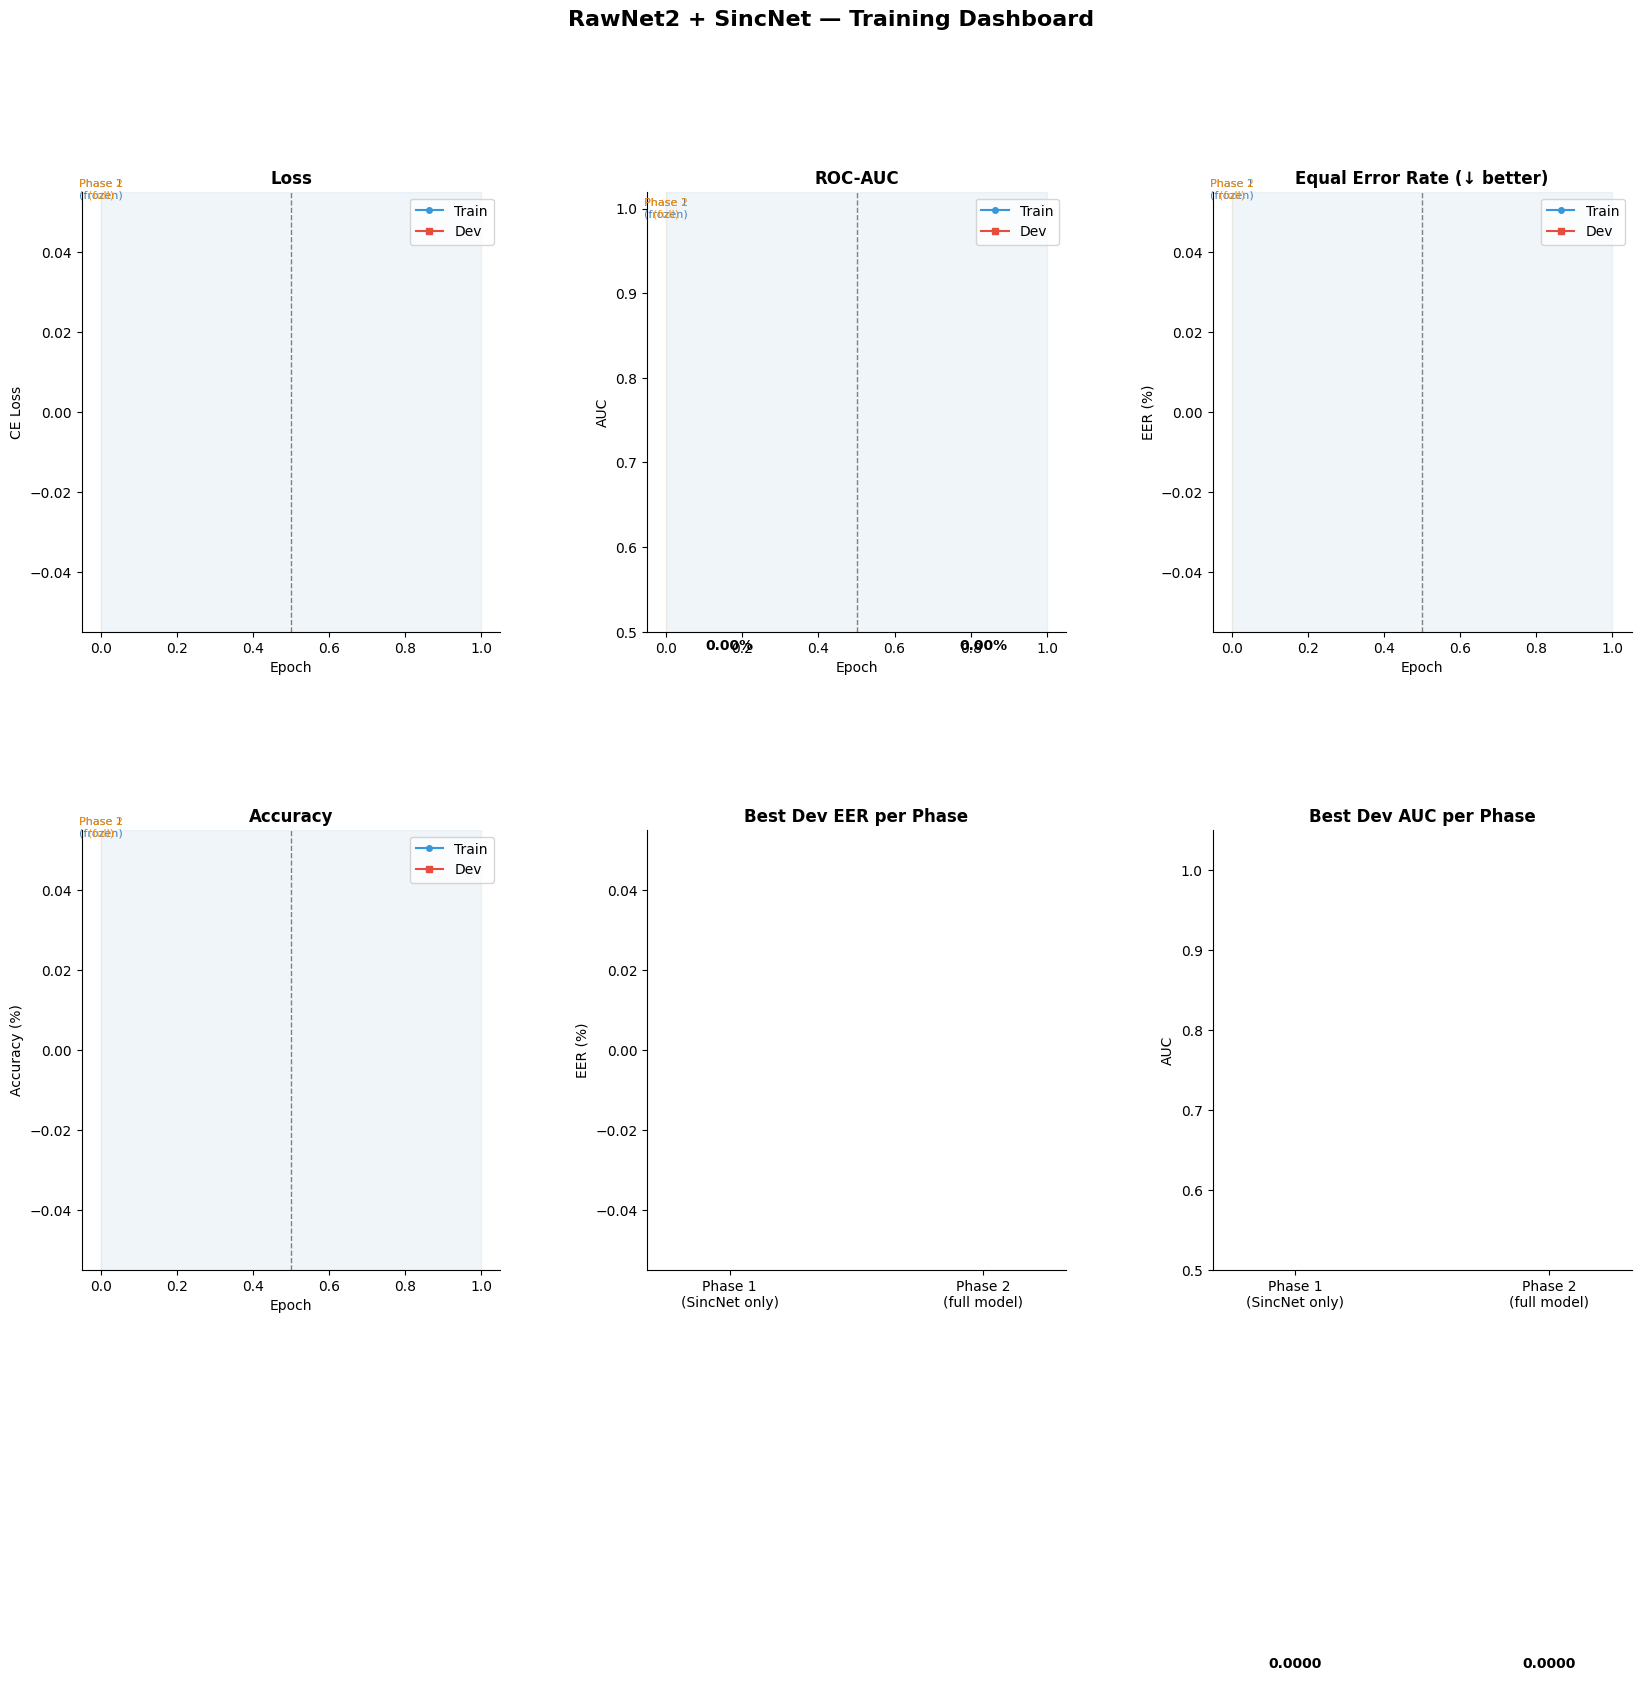

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ HF upload: graphs/training_dashboard.png


In [58]:
def shade_phases(ax, phases):
    p1_end = sum(1 for p in phases if p == "phase1")
    ax.axvspan(1, p1_end,            alpha=0.08, color="steelblue")
    ax.axvspan(p1_end, len(phases),  alpha=0.08, color="darkorange")
    ax.axvline(p1_end + 0.5, color="grey", ls="--", lw=1)
    ax.text(p1_end * 0.5,        ax.get_ylim()[1]*0.97, "Phase 1\n(frozen)",   ha="center", fontsize=8, color="steelblue")
    ax.text(p1_end + (len(phases)-p1_end)*0.5, ax.get_ylim()[1]*0.97, "Phase 2\n(full)", ha="center", fontsize=8, color="darkorange")

epochs_x = list(range(1, len(history["train_loss"]) + 1))

fig = plt.figure(figsize=(20, 14))
fig.suptitle("RawNet2 + SincNet — Training Dashboard", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)

def make_ax(pos, title, ylabel):
    ax = fig.add_subplot(pos)
    ax.set_title(title, fontweight="bold"); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    return ax

# Loss
ax1 = make_ax(gs[0,0], "Loss", "CE Loss")
ax1.plot(epochs_x, history["train_loss"], "o-", color="#3498db", ms=4, label="Train")
ax1.plot(epochs_x, history["dev_loss"],   "s-", color="#e74c3c", ms=4, label="Dev")
ax1.legend(); shade_phases(ax1, history["phase"])

# AUC
ax2 = make_ax(gs[0,1], "ROC-AUC", "AUC")
ax2.plot(epochs_x, history["train_auc"], "o-", color="#3498db", ms=4, label="Train")
ax2.plot(epochs_x, history["dev_auc"],   "s-", color="#e74c3c", ms=4, label="Dev")
ax2.set_ylim([0.5, 1.02]); ax2.legend(); shade_phases(ax2, history["phase"])

# EER
ax3 = make_ax(gs[0,2], "Equal Error Rate (↓ better)", "EER (%)")
ax3.plot(epochs_x, [e*100 for e in history["train_eer"]], "o-", color="#3498db", ms=4, label="Train")
ax3.plot(epochs_x, [e*100 for e in history["dev_eer"]],   "s-", color="#e74c3c", ms=4, label="Dev")
ax3.legend(); shade_phases(ax3, history["phase"])

# Accuracy
ax4 = make_ax(gs[1,0], "Accuracy", "Accuracy (%)")
ax4.plot(epochs_x, [a*100 for a in history["train_acc"]], "o-", color="#3498db", ms=4, label="Train")
ax4.plot(epochs_x, [a*100 for a in history["dev_acc"]],   "s-", color="#e74c3c", ms=4, label="Dev")
ax4.legend(); shade_phases(ax4, history["phase"])

# Phase comparison EER
ax5 = fig.add_subplot(gs[1,1])
p1_idx = [i for i,p in enumerate(history["phase"]) if p=="phase1"]
p2_idx = [i for i,p in enumerate(history["phase"]) if p=="phase2"]

# Guard: if history is empty (fresh session resume), use placeholder values
best_p1_eer_plot = min(history["dev_eer"][i] for i in p1_idx)*100 if p1_idx else 0
best_p2_eer_plot = min(history["dev_eer"][i] for i in p2_idx)*100 if p2_idx else 0
eers = [best_p1_eer_plot, best_p2_eer_plot]

bars = ax5.bar(["Phase 1\n(SincNet only)", "Phase 2\n(full model)"],
               eers, color=["steelblue","darkorange"], width=0.5)
for bar, val in zip(bars, eers):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{val:.2f}%",
             ha="center", fontweight="bold")
ax5.set_title("Best Dev EER per Phase", fontweight="bold")
ax5.set_ylabel("EER (%)"); ax5.spines[["top","right"]].set_visible(False)

# Phase comparison AUC
ax6 = fig.add_subplot(gs[1,2])
best_p1_auc_plot = max(history["dev_auc"][i] for i in p1_idx) if p1_idx else 0
best_p2_auc_plot = max(history["dev_auc"][i] for i in p2_idx) if p2_idx else 0
aucs = [best_p1_auc_plot, best_p2_auc_plot]

bars = ax6.bar(["Phase 1\n(SincNet only)", "Phase 2\n(full model)"],
               aucs, color=["steelblue","darkorange"], width=0.5)
for bar, val in zip(bars, aucs):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f"{val:.4f}",
             ha="center", fontweight="bold")
ax6.set_title("Best Dev AUC per Phase", fontweight="bold")
ax6.set_ylabel("AUC"); ax6.set_ylim([0.5, 1.05]); ax6.spines[["top","right"]].set_visible(False)

plt.savefig(f"{CFG['output_dir']}/training_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
hf_upload(f"{CFG['output_dir']}/training_dashboard.png", "graphs/training_dashboard.png",
          "Add training dashboard")

## 9. Visualization — Learned SincNet Filter Frequencies
This is the key visual for Step 4 — showing what frequency bands the model learned to focus on.

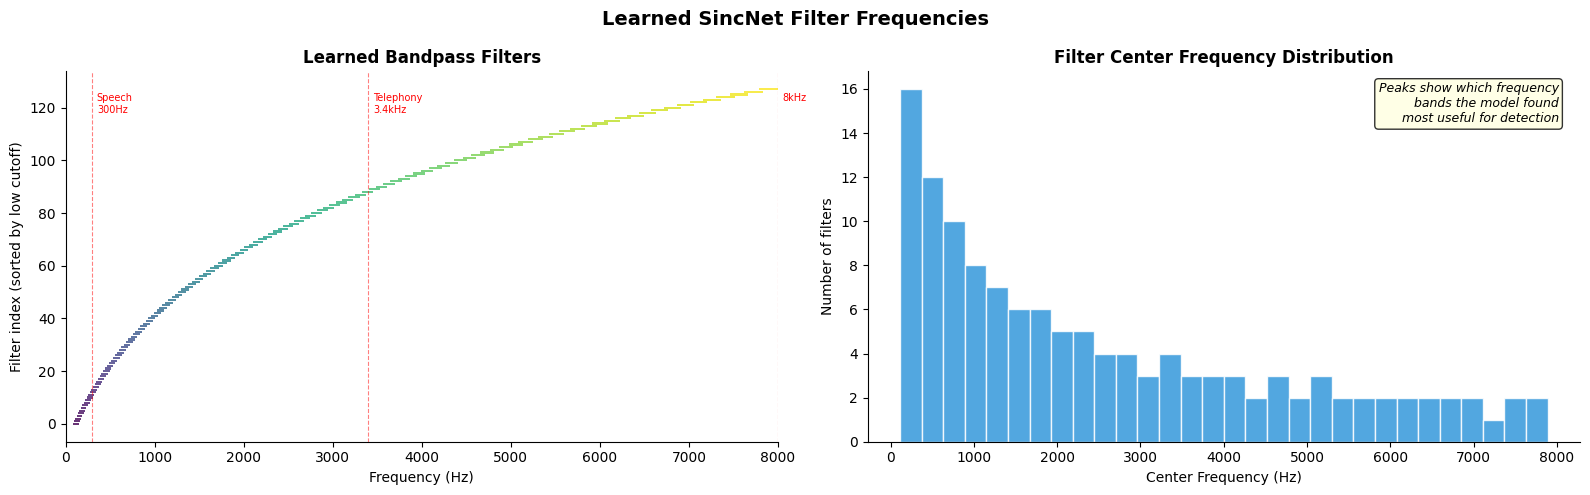

  ✓ HF upload: graphs/learned_filters.png

Filter frequency range: 80.0 Hz — 7996.3 Hz
Average bandwidth     : 111.4 Hz


In [59]:
core = model.module if isinstance(model, nn.DataParallel) else model
low_hz, high_hz = core.sinc_conv.get_learned_frequencies()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Learned SincNet Filter Frequencies", fontsize=14, fontweight="bold")

# ── Plot 1: Filter bank as horizontal bars ────────────────────────────────────
ax = axes[0]
sort_idx = np.argsort(low_hz)
for i, idx in enumerate(sort_idx):
    ax.barh(i, high_hz[idx] - low_hz[idx], left=low_hz[idx],
            height=0.8, color=plt.cm.viridis(i / len(sort_idx)), alpha=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Filter index (sorted by low cutoff)")
ax.set_title("Learned Bandpass Filters", fontweight="bold")
ax.set_xlim([0, CFG["sample_rate"] // 2])
# Annotate common speech bands
for freq, label in [(300, "Speech\n300Hz"), (3400, "Telephony\n3.4kHz"), (8000, "8kHz")]:
    ax.axvline(freq, color="red", ls="--", lw=0.8, alpha=0.5)
    ax.text(freq + 50, len(sort_idx)*0.98, label, color="red", fontsize=7, va="top")
ax.spines[["top","right"]].set_visible(False)

# ── Plot 2: Center frequency histogram ───────────────────────────────────────
ax2 = axes[1]
centers = (low_hz + high_hz) / 2
ax2.hist(centers, bins=30, color="#3498db", edgecolor="white", alpha=0.85)
ax2.set_xlabel("Center Frequency (Hz)")
ax2.set_ylabel("Number of filters")
ax2.set_title("Filter Center Frequency Distribution", fontweight="bold")
ax2.spines[["top","right"]].set_visible(False)

# Add text annotation explaining what we see
ax2.text(0.97, 0.97,
         "Peaks show which frequency\nbands the model found\nmost useful for detection",
         transform=ax2.transAxes, ha="right", va="top",
         fontsize=9, style="italic",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/learned_filters.png", dpi=150, bbox_inches="tight")
plt.show()
hf_upload(f"{CFG['output_dir']}/learned_filters.png", "graphs/learned_filters.png",
          "Add SincNet learned filter visualization")
print(f"\nFilter frequency range: {low_hz.min():.1f} Hz — {high_hz.max():.1f} Hz")
print(f"Average bandwidth     : {(high_hz - low_hz).mean():.1f} Hz")

## 10. Evaluation on Eval Set

In [60]:
# Load best Phase 2 weights
if best_p2_path and os.path.exists(best_p2_path):
    ckpt = torch.load(best_p2_path, map_location=DEVICE)
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded best phase 2 weights")

_, _, _, _, all_labels, all_scores = run_epoch(model, eval_loader, criterion, train=False)
all_labels = np.array(all_labels)
all_scores = np.array(all_scores)
all_preds  = (all_scores > 0.5).astype(int)

final_eer, eer_thresh = compute_eer(all_labels, all_scores)
final_auc = roc_auc_score(all_labels, all_scores)
final_acc = (all_preds == all_labels).mean()

print("=" * 50)
print("  FINAL EVAL SET RESULTS — RawNet2 + SincNet")
print("=" * 50)
print(f"  EER      : {final_eer*100:.2f}%")
print(f"  AUC      : {final_auc:.4f}")
print(f"  Accuracy : {final_acc*100:.2f}%")
print("=" * 50)
print()
print(classification_report(all_labels, all_preds, target_names=["Bonafide", "Spoof"]))

  FINAL EVAL SET RESULTS — RawNet2 + SincNet
  EER      : 29.49%
  AUC      : 0.7538
  Accuracy : 55.73%

              precision    recall  f1-score   support

    Bonafide       0.18      0.90      0.30      7355
       Spoof       0.98      0.52      0.68     63882

    accuracy                           0.56     71237
   macro avg       0.58      0.71      0.49     71237
weighted avg       0.90      0.56      0.64     71237



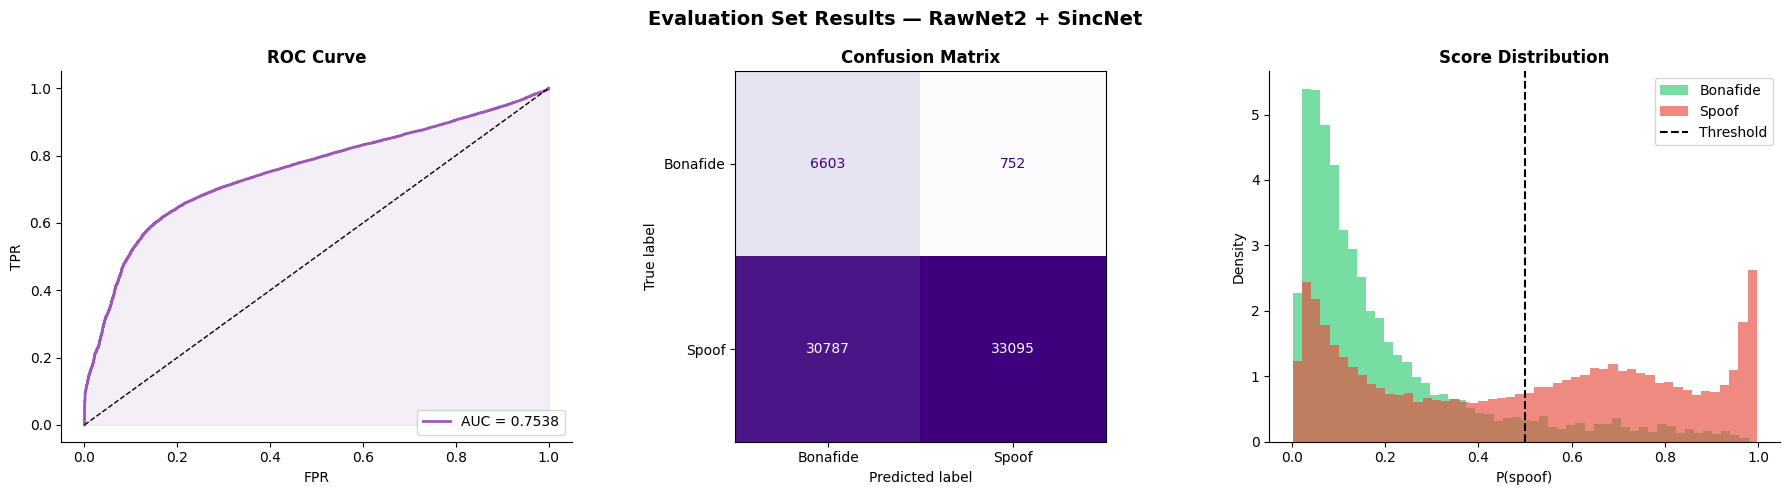

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ HF upload: graphs/eval_results.png


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Evaluation Set Results — RawNet2 + SincNet", fontsize=14, fontweight="bold")

# ROC
fpr, tpr, _ = roc_curve(all_labels, all_scores)
axes[0].plot(fpr, tpr, color="#9b59b6", lw=2, label=f"AUC = {final_auc:.4f}")
axes[0].plot([0,1],[0,1], "k--", lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#9b59b6")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(loc="lower right")
axes[0].spines[["top","right"]].set_visible(False)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["Bonafide","Spoof"]).plot(
    ax=axes[1], colorbar=False, cmap="Purples")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# Score distribution
axes[2].hist(all_scores[all_labels==0], bins=50, alpha=0.65,
             color="#2ecc71", label="Bonafide", density=True)
axes[2].hist(all_scores[all_labels==1], bins=50, alpha=0.65,
             color="#e74c3c", label="Spoof", density=True)
axes[2].axvline(0.5, color="black", ls="--", lw=1.5, label="Threshold")
axes[2].set_title("Score Distribution", fontweight="bold")
axes[2].set_xlabel("P(spoof)"); axes[2].set_ylabel("Density")
axes[2].legend(); axes[2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/eval_results.png", dpi=150, bbox_inches="tight")
plt.show()
hf_upload(f"{CFG['output_dir']}/eval_results.png", "graphs/eval_results.png", "Add eval results")

## 11. Save Final Model + Push to HuggingFace

In [62]:
SAVE_DIR = f"{CFG['output_dir']}/final_model"
os.makedirs(SAVE_DIR, exist_ok=True)

core = model.module if isinstance(model, nn.DataParallel) else model

# 1. Weights only (for inference — small file)
torch.save(core.state_dict(), f"{SAVE_DIR}/rawnet2_sincnet_final.pth")

# 2. SincNet frontend weights only (useful for analysis / reuse)
torch.save(core.sinc_conv.state_dict(), f"{SAVE_DIR}/sincnet_frontend_only.pth")

# 3. Learned filter frequencies as numpy (for visualization in your project)
low_hz, high_hz = core.sinc_conv.get_learned_frequencies()
np.save(f"{SAVE_DIR}/learned_filter_low_hz.npy",  low_hz)
np.save(f"{SAVE_DIR}/learned_filter_high_hz.npy", high_hz)

# 4. Config JSON
model_config = {
    "architecture"        : "RawNet2 + SincNet learnable frontend",
    "sinc_num_filters"    : CFG["sinc_num_filters"],
    "sinc_kernel_size"    : CFG["sinc_kernel_size"],
    "sinc_min_low_hz"     : CFG["sinc_min_low_hz"],
    "sinc_min_band_hz"    : CFG["sinc_min_band_hz"],
    "rawnet2_filters"     : CFG["rawnet2_filters"],
    "rawnet2_gru_nodes"   : CFG["rawnet2_gru_nodes"],
    "rawnet2_gru_layers"  : CFG["rawnet2_gru_layers"],
    "rawnet2_nb_fc_node"  : CFG["rawnet2_nb_fc_node"],
    "rawnet2_nb_classes"  : CFG["rawnet2_nb_classes"],
    "sample_rate"         : CFG["sample_rate"],
    "max_audio_len_sec"   : CFG["max_audio_len_sec"],
    "dataset"             : "ASVspoof 2019 LA",
    "pretrained_from"     : "librifake_pretrained_lambda0.5_epoch_25.pth",
    "training_phases"     : ["phase1: SincNet only", "phase2: full end-to-end"],
    "eval_eer"            : round(final_eer * 100, 4),
    "eval_auc"            : round(final_auc, 4),
    "eval_acc"            : round(final_acc * 100, 4),
    "maps_to"             : "src/models/vocoder/",
}
with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(model_config, f, indent=2)

# 5. README / model card
readme = f"""# Deepfake Voice Detection — RawNet2 + SincNet Frontend

## What this is
RawNet2 with a **learnable SincNet frontend** replacing fixed sinc filters.  
The model learns which frequency bands are most discriminative for deepfake detection.

## Architecture
```
Raw Audio [B,1,T]
  → SincConv1d ({CFG['sinc_num_filters']} learnable bandpass filters, kernel={CFG['sinc_kernel_size']})
  → BN → LeakyReLU → MaxPool → Dropout
  → ResBlock x6 (RawNet2 body, pretrained on Librifake)
  → GRU ({CFG['rawnet2_gru_nodes']} units, {CFG['rawnet2_gru_layers']} layers)
  → FC({CFG['rawnet2_nb_fc_node']}) → FC(2) → Softmax
```

## Training
- **Base weights**: `librifake_pretrained_lambda0.5_epoch_25.pth`
- **Dataset**: ASVspoof 2019 LA
- **Phase 1**: SincNet frontend only, {CFG['epochs_phase1']} epochs (body frozen)
- **Phase 2**: Full end-to-end, {CFG['epochs_phase2']} epochs

## Results (ASVspoof 2019 LA Eval)
| Metric | Value |
|--------|-------|
| EER | {final_eer*100:.2f}% |
| AUC | {final_auc:.4f} |
| Accuracy | {final_acc*100:.2f}% |

## Files
- `rawnet2_sincnet_final.pth` — full model weights
- `sincnet_frontend_only.pth` — SincNet frontend only
- `learned_filter_low_hz.npy` / `learned_filter_high_hz.npy` — learned filter frequencies
- `config.json` — architecture config for reconstruction
- `checkpoints/` — per-epoch checkpoints for both phases
- `graphs/` — training curves, filter visualization, eval results

## Maps to
`src/models/vocoder/` in the Deepfake Voice Detection project
"""
with open(f"{SAVE_DIR}/README.md", "w") as f:
    f.write(readme)

print("Local save complete ✓")
for fname in os.listdir(SAVE_DIR):
    size = os.path.getsize(f"{SAVE_DIR}/{fname}") / 1e6
    print(f"  {fname}  ({size:.1f} MB)")

Local save complete ✓
  learned_filter_high_hz.npy  (0.0 MB)
  sincnet_frontend_only.pth  (0.0 MB)
  config.json  (0.0 MB)
  README.md  (0.0 MB)
  learned_filter_low_hz.npy  (0.0 MB)
  rawnet2_sincnet_final.pth  (68.5 MB)


In [63]:
# Push all final model files to HuggingFace
final_files = [
    (f"{SAVE_DIR}/rawnet2_sincnet_final.pth",       "rawnet2_sincnet_final.pth"),
    (f"{SAVE_DIR}/sincnet_frontend_only.pth",        "sincnet_frontend_only.pth"),
    (f"{SAVE_DIR}/learned_filter_low_hz.npy",        "learned_filter_low_hz.npy"),
    (f"{SAVE_DIR}/learned_filter_high_hz.npy",       "learned_filter_high_hz.npy"),
    (f"{SAVE_DIR}/config.json",                      "config.json"),
    (f"{SAVE_DIR}/README.md",                        "README.md"),
]

for local, remote in final_files:
    hf_upload(local, remote, f"Final model upload — EER={final_eer*100:.2f}%")

print(f"\n🎉 All files at: https://huggingface.co/{HF_REPO_ID}")
print(f"\nYour HF repo structure:")
print(f"  {HF_REPO_ID}/")
print(f"  ├── rawnet2_sincnet_final.pth       ← load this for inference")
print(f"  ├── sincnet_frontend_only.pth")
print(f"  ├── learned_filter_*.npy            ← for visualization in your GUI")
print(f"  ├── config.json")
print(f"  ├── README.md")
print(f"  ├── checkpoints/                    ← every epoch checkpoint")
print(f"  └── graphs/                         ← all training visualizations")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ HF upload: rawnet2_sincnet_final.pth


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

  ✓ HF upload: learned_filter_low_hz.npy


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ✓ HF upload: learned_filter_high_hz.npy
  ✓ HF upload: config.json
  ✓ HF upload: README.md

🎉 All files at: https://huggingface.co/IshatShivhare/deepfake-rawnet2-sincnet

Your HF repo structure:
  IshatShivhare/deepfake-rawnet2-sincnet/
  ├── rawnet2_sincnet_final.pth       ← load this for inference
  ├── sincnet_frontend_only.pth
  ├── learned_filter_*.npy            ← for visualization in your GUI
  ├── config.json
  ├── README.md
  ├── checkpoints/                    ← every epoch checkpoint
  └── graphs/                         ← all training visualizations


## 12. Quick Inference Test

In [64]:
def predict_file(audio_path: str, model, sr: int = 16000):
    core = model.module if isinstance(model, nn.DataParallel) else model
    core.eval()

    wav, orig_sr = torchaudio.load(audio_path)
    if wav.shape[0] > 1:
        wav = wav.mean(0, keepdim=True)
    if orig_sr != sr:
        wav = T.Resample(orig_sr, sr)(wav)
    wav = wav.squeeze(0)
    if wav.shape[0] < MAX_LEN:
        wav = F.pad(wav, (0, MAX_LEN - wav.shape[0]))
    else:
        wav = wav[:MAX_LEN]

    inp = wav.unsqueeze(0).unsqueeze(0).to(DEVICE)  # [1,1,T]
    with torch.no_grad():
        logits = core(inp)                           # [1, 2]
        prob   = F.softmax(logits, dim=1)[0, 1].item()

    verdict = "🔴 SPOOF (Fake)" if prob > 0.5 else "🟢 BONAFIDE (Real)"
    print(f"  File     : {os.path.basename(audio_path)}")
    print(f"  P(spoof) : {prob:.4f}")
    print(f"  Verdict  : {verdict}")
    return prob

real_file  = os.path.join(eval_audio, eval_df[eval_df.label==0].iloc[0]["file"] + ".flac")
spoof_file = os.path.join(eval_audio, eval_df[eval_df.label==1].iloc[0]["file"] + ".flac")

print("--- Real sample ---")
predict_file(real_file, model)
print()
print("--- Spoof sample ---")
predict_file(spoof_file, model)

--- Real sample ---
  File     : LA_E_5849185.flac
  P(spoof) : 0.0170
  Verdict  : 🟢 BONAFIDE (Real)

--- Spoof sample ---
  File     : LA_E_2834763.flac
  P(spoof) : 0.5426
  Verdict  : 🔴 SPOOF (Fake)


0.542575478553772

---
## Summary

| What | Detail |
|------|--------|
| **Step 4 improvement** | Fixed sinc filters → Learnable SincConv1d with mel-scale init |
| **Pretrained base** | `librifake_pretrained_lambda0.5_epoch_25.pth` (your existing weights) |
| **Phase 1** | SincNet frontend only trained — body frozen |
| **Phase 2** | Full end-to-end fine-tuning with differential LR |
| **Checkpoints** | Every epoch → HuggingFace `checkpoints/` folder |
| **Key visualization** | `graphs/learned_filters.png` — what frequencies the model learned |
| **Maps to** | `src/models/vocoder/` in your project |
| **Next step** | Step 5 — Meta-learner ensemble combining RawNet2 + Wav2Vec2 scores |